# Passing Quality Model

Predicting `delta_Passing_quality` (post − pre) for midfielders.

**Two models:**
1. **Naive**: only `from_Passing_quality` → does pre-transfer level alone predict the change?
2. **Full**: `from_Passing_quality` + 7 delta team qualities → does tactical context help?

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
# ── Load data ──
DATA_DIR = "../../../../thesis_data/processed_data/thesis_model_dataset/active/"
df = pd.read_parquet(DATA_DIR + "within_league_transfers_v5.parquet")
mf = df[df["from_position"] == "Midfielder"].copy()
print(f"Midfielders: {len(mf):,}")

Midfielders: 5,230


## Feature Engineering

In [4]:
# Target: delta in Passing quality
mf["delta_Passing_quality"] = mf["to_Passing quality"] - mf["from_Passing quality"]

# Team quality dimensions
TEAM_QUALITIES = ["ATTACK", "ATTACKING_TRANSITION", "CHANCE_CREATION",
                  "DEFENCE", "DEFENSIVE_TRANSITION", "OUTCOME", "PENETRATION"]

# Delta team qualities (destination - origin)
for tq in TEAM_QUALITIES:
    mf[f"delta_tq_{tq}"] = mf[f"to_q_{tq}"] - mf[f"from_q_proj_{tq}"]

delta_tq_cols = [f"delta_tq_{tq}" for tq in TEAM_QUALITIES]

# Drop rows with missing team qualities
cols_needed = ["from_Passing quality", "delta_Passing_quality"] + delta_tq_cols
n_before = len(mf)
mf = mf.dropna(subset=cols_needed)
print(f"Dropped {n_before - len(mf)} rows with missing team qualities")
print(f"Remaining: {len(mf):,}")

print(f"\nTarget: delta_Passing_quality")
print(f"  mean = {mf['delta_Passing_quality'].mean():.4f}")
print(f"  std  = {mf['delta_Passing_quality'].std():.4f}")
print()
print(f"Delta team quality columns ({len(delta_tq_cols)}):")

Dropped 314 rows with missing team qualities
Remaining: 4,916

Target: delta_Passing_quality
  mean = -0.0107
  std  = 0.5681

Delta team quality columns (7):


In [5]:
# Train/test split (80/20)
train, test = train_test_split(mf, test_size=0.2, random_state=42)
print(f"Train: {len(train):,}  |  Test: {len(test):,}")

Train: 3,932  |  Test: 984


---
## Model 1: Naive (Pre-Quality Only)

$$\Delta PQ = \alpha + \beta \cdot \text{from\_Passing\_quality}$$

If this model already predicts well, tactical context may not add much.

In [6]:
# ── Naive model ──
naive_features = ["from_Passing quality"]

X_train_naive = sm.add_constant(train[naive_features])
X_test_naive  = sm.add_constant(test[naive_features])
y_train = train["delta_Passing_quality"]
y_test  = test["delta_Passing_quality"]

naive_model = sm.OLS(y_train, X_train_naive).fit()
print(naive_model.summary())

                              OLS Regression Results                             
Dep. Variable:     delta_Passing_quality   R-squared:                       0.156
Model:                               OLS   Adj. R-squared:                  0.156
Method:                    Least Squares   F-statistic:                     726.1
Date:                   Fri, 20 Mar 2026   Prob (F-statistic):          6.68e-147
Time:                           11:33:48   Log-Likelihood:                -3032.8
No. Observations:                   3932   AIC:                             6070.
Df Residuals:                       3930   BIC:                             6082.
Df Model:                              1                                         
Covariance Type:               nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
co

In [7]:
# Naive model — test set performance
naive_pred = naive_model.predict(X_test_naive)
naive_r2  = r2_score(y_test, naive_pred)
naive_mae = mean_absolute_error(y_test, naive_pred)

print("Naive Model — Test Set")
print(f"  R²:  {naive_r2:.4f}")
print(f"  MAE: {naive_mae:.4f}")

Naive Model — Test Set
  R²:  0.2023
  MAE: 0.3924


---
## Model 2: Full (Pre-Quality + All Delta Team Qualities)

$$\Delta PQ = \alpha + \beta \cdot \text{from\_PQ} + \sum_{k=1}^{7} \gamma_k \cdot \Delta TQ_k$$

Does knowing *how* the tactical environment changes help predict the change in passing quality?

In [8]:
# ── Full model ──
full_features = ["from_Passing quality"] + delta_tq_cols

X_train_full = sm.add_constant(train[full_features])
X_test_full  = sm.add_constant(test[full_features])

full_model = sm.OLS(y_train, X_train_full).fit()
print(full_model.summary())

                              OLS Regression Results                             
Dep. Variable:     delta_Passing_quality   R-squared:                       0.218
Model:                               OLS   Adj. R-squared:                  0.217
Method:                    Least Squares   F-statistic:                     136.9
Date:                   Fri, 20 Mar 2026   Prob (F-statistic):          2.67e-203
Time:                           11:33:48   Log-Likelihood:                -2882.2
No. Observations:                   3932   AIC:                             5782.
Df Residuals:                       3923   BIC:                             5839.
Df Model:                              8                                         
Covariance Type:               nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------

In [9]:
# Full model — test set performance
full_pred = full_model.predict(X_test_full)
full_r2  = r2_score(y_test, full_pred)
full_mae = mean_absolute_error(y_test, full_pred)

print("Full Model — Test Set")
print(f"  R²:  {full_r2:.4f}")
print(f"  MAE: {full_mae:.4f}")

Full Model — Test Set
  R²:  0.2441
  MAE: 0.3831


---
## Comparison

In [10]:
# Side-by-side comparison
comparison = pd.DataFrame({
    "Model": ["1. Naive (pre-quality only)", "2. Full (pre-quality + delta TQ)"],
    "R2_test": [naive_r2, full_r2],
    "MAE_test": [naive_mae, full_mae],
    "R2_adj_train": [naive_model.rsquared_adj, full_model.rsquared_adj],
    "AIC": [naive_model.aic, full_model.aic],
    "BIC": [naive_model.bic, full_model.bic],
    "N_features": [len(naive_features), len(full_features)],
})
print(comparison.to_string(index=False, float_format="{:.4f}".format))

r2_gain = full_r2 - naive_r2
print(f"\nR² gain from tactical context: {r2_gain:+.4f}")
print(f"MAE reduction: {naive_mae - full_mae:+.4f}")

                           Model  R2_test  MAE_test  R2_adj_train       AIC       BIC  N_features
     1. Naive (pre-quality only)   0.2023    0.3924        0.1557 6069.6131 6082.1669           1
2. Full (pre-quality + delta TQ)   0.2441    0.3831        0.2166 5782.3526 5838.8447           8

R² gain from tactical context: +0.0418
MAE reduction: +0.0092


---
## Coefficient Analysis (Full Model)

Which delta team qualities matter most for predicting passing quality change?

In [11]:
# Coefficient table for the full model
coef_df = pd.DataFrame({
    "Feature": full_model.params.index,
    "Coefficient": full_model.params.values,
    "Std Error": full_model.bse.values,
    "t-stat": full_model.tvalues.values,
    "p-value": full_model.pvalues.values,
})

# Sort by absolute coefficient (skip constant)
coef_df_features = coef_df[coef_df["Feature"] != "const"].sort_values("Coefficient", key=abs, ascending=False)
print(coef_df_features.to_string(index=False, float_format="{:.4f}".format))

                      Feature  Coefficient  Std Error   t-stat  p-value
         from_Passing quality      -0.2923     0.0113 -25.8641   0.0000
              delta_tq_ATTACK       0.0957     0.0096   9.9838   0.0000
             delta_tq_DEFENCE       0.0597     0.0089   6.6749   0.0000
             delta_tq_OUTCOME       0.0360     0.0076   4.7551   0.0000
delta_tq_DEFENSIVE_TRANSITION      -0.0177     0.0102  -1.7336   0.0831
delta_tq_ATTACKING_TRANSITION      -0.0130     0.0121  -1.0718   0.2839
         delta_tq_PENETRATION      -0.0111     0.0106  -1.0422   0.2974
     delta_tq_CHANCE_CREATION      -0.0076     0.0115  -0.6598   0.5094


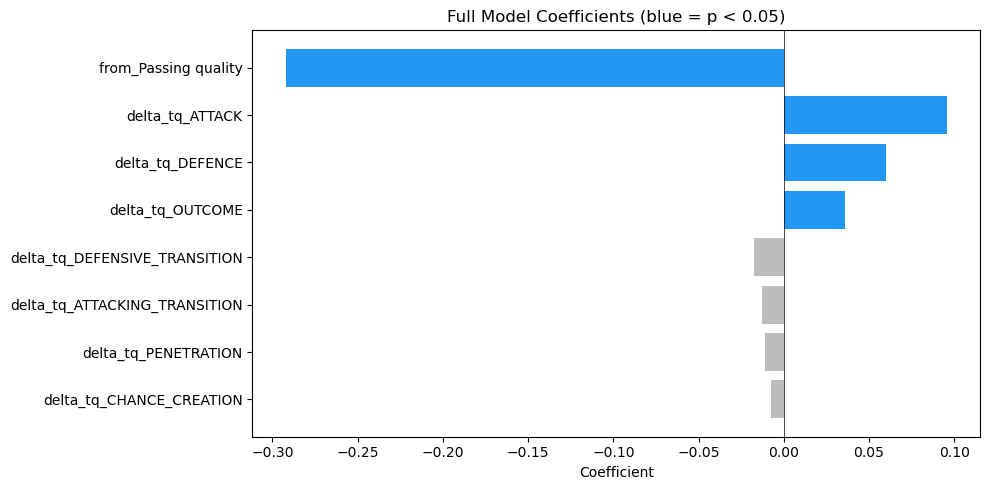

In [12]:
# Visualize coefficients
fig, ax = plt.subplots(figsize=(10, 5))
features = coef_df_features["Feature"].values
coefs = coef_df_features["Coefficient"].values
pvals = coef_df_features["p-value"].values

colors = ["#2196F3" if p < 0.05 else "#BDBDBD" for p in pvals]
ax.barh(range(len(features)), coefs, color=colors)
ax.set_yticks(range(len(features)))
ax.set_yticklabels(features, fontsize=10)
ax.axvline(0, color="black", linewidth=0.5)
ax.set_xlabel("Coefficient")
ax.set_title("Full Model Coefficients (blue = p < 0.05)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---
## Diagnostics

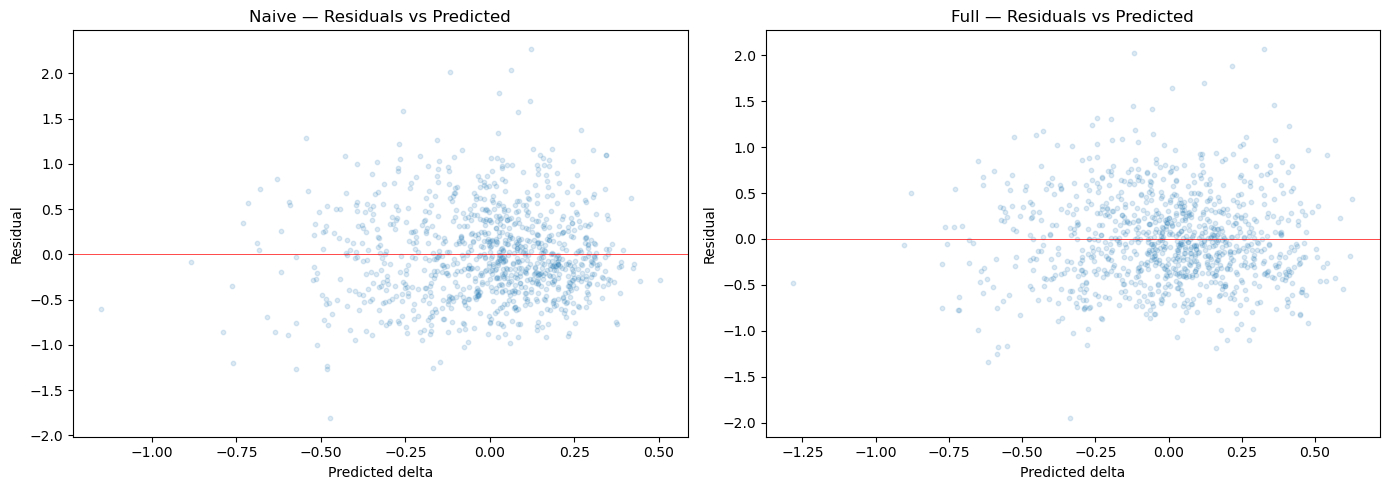

In [13]:
# Residual plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, name, pred in [(axes[0], "Naive", naive_pred), (axes[1], "Full", full_pred)]:
    resid = y_test - pred
    ax.scatter(pred, resid, alpha=0.15, s=10)
    ax.axhline(0, color="red", linewidth=0.5)
    ax.set_xlabel("Predicted delta")
    ax.set_ylabel("Residual")
    ax.set_title(f"{name} — Residuals vs Predicted")

plt.tight_layout()
plt.show()

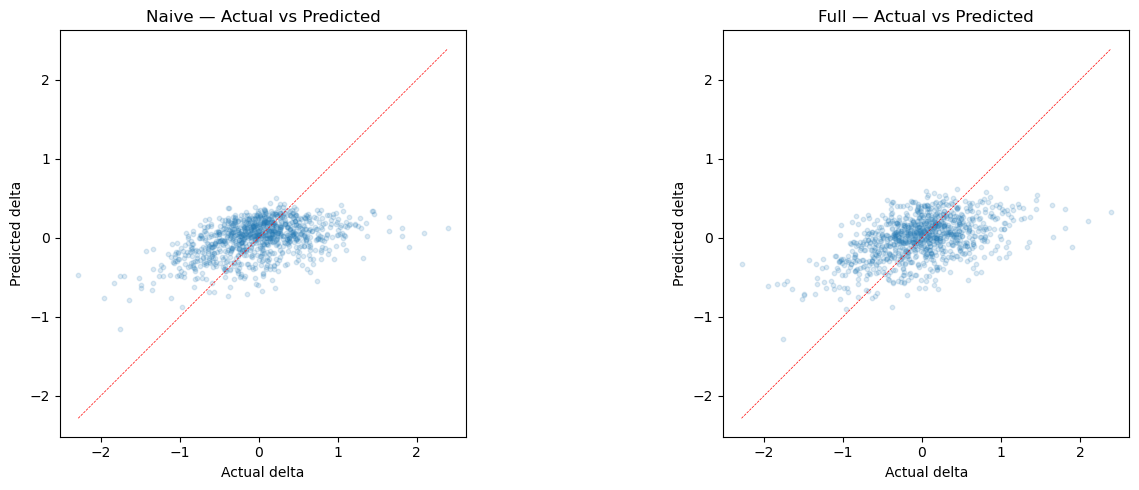

In [14]:
# Actual vs predicted scatter
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, name, pred in [(axes[0], "Naive", naive_pred), (axes[1], "Full", full_pred)]:
    ax.scatter(y_test, pred, alpha=0.15, s=10)
    lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
    ax.plot(lims, lims, "r--", linewidth=0.5)
    ax.set_xlabel("Actual delta")
    ax.set_ylabel("Predicted delta")
    ax.set_title(f"{name} — Actual vs Predicted")
    ax.set_aspect("equal")

plt.tight_layout()
plt.show()